I. Tiền xử lí dữ liệu

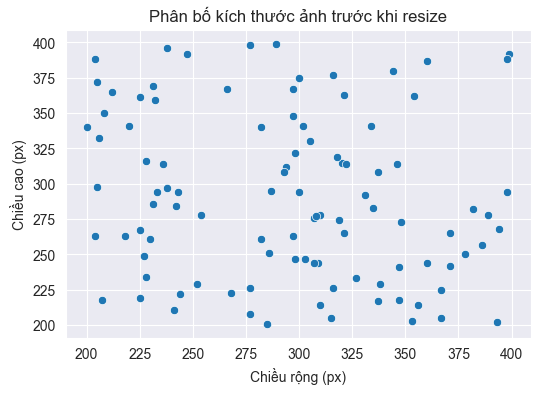

In [33]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.color import rgb2gray

# Giả sử bạn có list kích thước gốc `original_shapes`
original_shapes = [(random.randint(200,400), random.randint(200,400)) for _ in range(100)]
widths, heights = zip(*original_shapes)

plt.figure(figsize=(6,4))
sns.scatterplot(x=widths, y=heights)
plt.title("Phân bố kích thước ảnh trước khi resize")
plt.xlabel("Chiều rộng (px)")
plt.ylabel("Chiều cao (px)")
plt.show()

1. Làm sạch dữ liệu

In [34]:
import os
import cv2
import imutils
from tqdm import tqdm
import numpy as np


# HÀM CẮT ẢNH THEO VÙNG CHÍNH
def crop_img(img):
    """
    Cắt ảnh để loại bỏ vùng nền dư thừa, chỉ giữ lại phần chứa vật thể chính.
    Các bước:
        1. Chuyển ảnh sang thang xám (grayscale).
        2. Làm mờ ảnh để giảm nhiễu.
        3. Ngưỡng hoá (threshold) để tách vật thể ra khỏi nền.
        4. Dò các đường biên (contours) và chọn contour lớn nhất.
        5. Xác định toạ độ biên trên - dưới - trái - phải của contour.
        6. Cắt ảnh theo các biên đó để lấy vùng vật thể chính.
    """
    # Chuyển ảnh sang thang xám và làm mờ
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Ngưỡng hóa để tách vật thể ra khỏi nền
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Tìm contour lớn nhất (vật thể chính)
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # Lấy các điểm biên của contour
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Cắt ảnh theo vùng vật thể chính
    return img[extTop[1]:extBot[1], extLeft[0]:extRight[0]].copy()


# CHUẨN BỊ ĐƯỜNG DẪN VÀ THAM SỐ XỬ LÝ
BASE_DIR = os.getcwd()  # Thư mục hiện tại (vì trong Notebook không có __file__)
training = os.path.join(BASE_DIR, "data", "raw", "Training")  # Thư mục chứa ảnh train gốc
testing = os.path.join(BASE_DIR, "data", "raw", "Testing")  # Thư mục chứa ảnh test gốc
IMG_SIZE = 128  # Kích thước chuẩn của ảnh sau xử lý

print("Training path:", training)
print("Testing path:", testing)

# XỬ LÝ TỪNG TẬP DỮ LIỆU (TRAINING & TESTING)
for dataset, name in [(training, "Training"), (testing, "Testing")]:
    print(f"\nĐang xử lý tập {name}...")

    # Lặp qua từng thư mục con (mỗi thư mục tương ứng 1 lớp nhãn)
    for dir in os.listdir(dataset):
        path = os.path.join(dataset, dir)  # Đường dẫn đến thư mục ảnh gốc
        save_path = os.path.join(BASE_DIR, "data", "cleaned", name, dir)  # Nơi lưu ảnh sau khi xử lý

        # Nếu thư mục cleaned đã có dữ liệu thì bỏ qua (tránh xử lý lại)
        if os.path.exists(save_path) and len(os.listdir(save_path)) > 0:
            print(f"Bỏ qua {name}/{dir} (đã có dữ liệu cleaned).")
            continue

        # Nếu chưa có thư mục cleaned thì tạo mới
        os.makedirs(save_path, exist_ok=True)
        print(f"Đang xử lý {name}/{dir}...")

        # Lặp qua từng ảnh trong thư mục, đọc và xử lý
        for img in tqdm(os.listdir(path), desc=f"{name}/{dir}", ncols=80):
            image_path = os.path.join(path, img)
            image = cv2.imread(image_path)

            # Nếu ảnh bị lỗi hoặc không đọc được thì bỏ qua
            if image is None:
                print(f"Lỗi đọc ảnh: {image_path}")
                continue

            try:
                # Cắt vùng vật thể chính
                cropped = crop_img(image)
                # Chuẩn hoá kích thước ảnh
                resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
                # Ghi ảnh đã xử lý vào thư mục đích
                cv2.imwrite(os.path.join(save_path, img), resized)
            except Exception as e:
                # Nếu có lỗi trong quá trình xử lý ảnh (VD: không tìm được contour)
                print(f"Lỗi khi xử lý ảnh {img}: {e}")

# HOÀN TẤT QUY TRÌNH
print("\nHoàn tất! Dữ liệu đã được lưu tại:")
print(os.path.join(BASE_DIR, "data", "cleaned"))

Training path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Training
Testing path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Testing

Đang xử lý tập Training...
Bỏ qua Training/glioma (đã có dữ liệu cleaned).
Bỏ qua Training/meningioma (đã có dữ liệu cleaned).
Bỏ qua Training/notumor (đã có dữ liệu cleaned).
Bỏ qua Training/pituitary (đã có dữ liệu cleaned).

Đang xử lý tập Testing...
Bỏ qua Testing/glioma (đã có dữ liệu cleaned).
Bỏ qua Testing/meningioma (đã có dữ liệu cleaned).
Bỏ qua Testing/notumor (đã có dữ liệu cleaned).
Bỏ qua Testing/pituitary (đã có dữ liệu cleaned).

Hoàn tất! Dữ liệu đã được lưu tại:
D:\NAM BA\Semester 1\ML\Lab\project_ml\data\cleaned


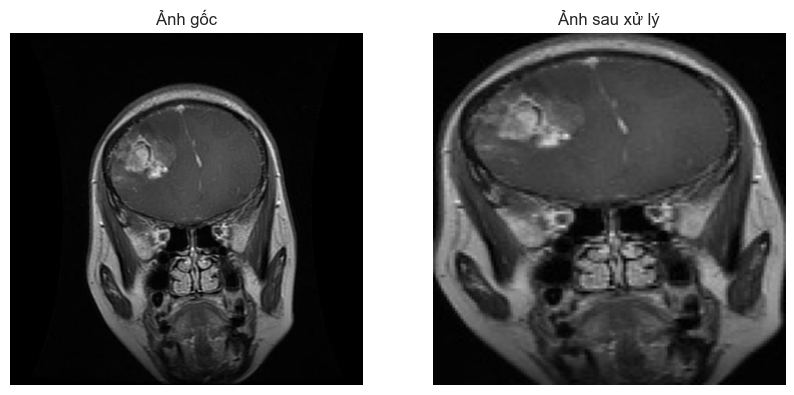

In [35]:
import matplotlib.pyplot as plt

# HIỂN THỊ ẢNH MẪU TRƯỚC VÀ SAU KHI XỬ LÝ

# Chọn 1 thư mục lớp đầu tiên
sample_class = os.listdir(training)[0]
sample_img_name = os.listdir(os.path.join(training, sample_class))[0]

# Đường dẫn ảnh gốc và ảnh đã xử lý
raw_img_path = os.path.join(training, sample_class, sample_img_name)
cleaned_img_path = os.path.join(BASE_DIR, "data", "cleaned", "Training", sample_class, sample_img_name)

# Đọc ảnh
raw_img = cv2.cvtColor(cv2.imread(raw_img_path), cv2.COLOR_BGR2RGB)
cleaned_img = cv2.cvtColor(cv2.imread(cleaned_img_path), cv2.COLOR_BGR2RGB)

# Hiển thị
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cleaned_img)
plt.title("Ảnh sau xử lý")
plt.axis("off")

plt.show()

2 Chuẩn hóa dữ liệu.

2.1 Xử lý

In [36]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


# HÀM ĐỌC DỮ LIỆU ẢNH
def load_images_from_folder(base_path):
    X, y = [], []
    classes = os.listdir(base_path)
    print(f"Các lớp tìm thấy: {classes}")

    for label in classes:
        folder = os.path.join(base_path, label)
        for file in tqdm(os.listdir(folder), desc=f"Đọc {label}", ncols=80):
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Ảnh lỗi: {file}")
                continue
            if img.shape != (128, 128, 3):
                print(f"Ảnh sai kích thước: {file}, shape={img.shape}")
                continue
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

# MAIN
train_path = "data/cleaned/Training"
test_path = "data/cleaned/Testing"

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("Không tìm thấy thư mục dữ liệu. Kiểm tra lại đường dẫn!")
    print("Training:", os.path.abspath(train_path))
    print("Testing:", os.path.abspath(test_path))
    exit()

X_train, y_train = load_images_from_folder(train_path)
X_test, y_test = load_images_from_folder(test_path)

print("\nĐọc dữ liệu xong.")
print("Training:", X_train.shape, "Testing:", X_test.shape)
print("Số lớp:", len(np.unique(y_train)))
print("Các nhãn:", np.unique(y_train))

# Mã hoá nhãn
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

onehot_encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = onehot_encoder.fit_transform(y_train_encoded.reshape(-1, 1))
y_test_onehot = onehot_encoder.transform(y_test_encoded.reshape(-1, 1))

# Chuẩn hoá ảnh về [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("\nThống kê dữ liệu sau chuẩn hoá:")
print("Train set:", X_train.shape, y_train_encoded.shape)
print("Test set:", X_test.shape, y_test_encoded.shape)
print("Giá trị pixel min:", np.min(X_train), "max:", np.max(X_train))
print("Số lớp:", len(label_encoder.classes_))
print("Tên lớp:", label_encoder.classes_)

Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']


Đọc pituitary: 100%|████████████████████████| 1457/1457 [00:37<00:00, 38.72it/s]


Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']


Đọc pituitary: 100%|██████████████████████████| 300/300 [00:08<00:00, 35.02it/s]



Đọc dữ liệu xong.
Training: (5712, 128, 128, 3) Testing: (1311, 128, 128, 3)
Số lớp: 4
Các nhãn: ['glioma' 'meningioma' 'notumor' 'pituitary']

Thống kê dữ liệu sau chuẩn hoá:
Train set: (5712, 128, 128, 3) (5712,)
Test set: (1311, 128, 128, 3) (1311,)
Giá trị pixel min: 0.0 max: 2.007874
Số lớp: 4
Tên lớp: ['glioma' 'meningioma' 'notumor' 'pituitary']


2.2 Biểu đồ mô tả trực quan

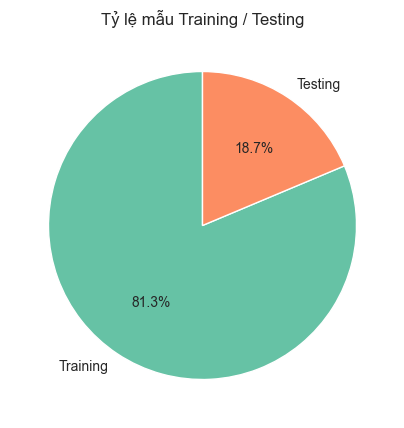

In [37]:
sizes = [len(y_train), len(y_test)]
labels = ['Training', 'Testing']

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66c2a5','#fc8d62'])
plt.title("Tỷ lệ mẫu Training / Testing")
plt.show()

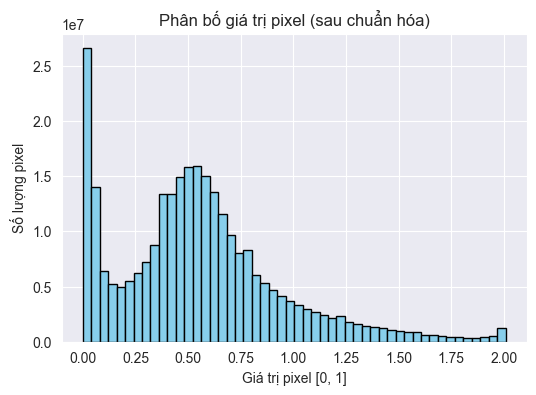

In [38]:
# Flatten toàn bộ pixel để xem histogram
pixels = X_train.flatten()

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=50, color='skyblue', edgecolor='black')
plt.title("Phân bố giá trị pixel (sau chuẩn hóa)")
plt.xlabel("Giá trị pixel [0, 1]")
plt.ylabel("Số lượng pixel")
plt.show()

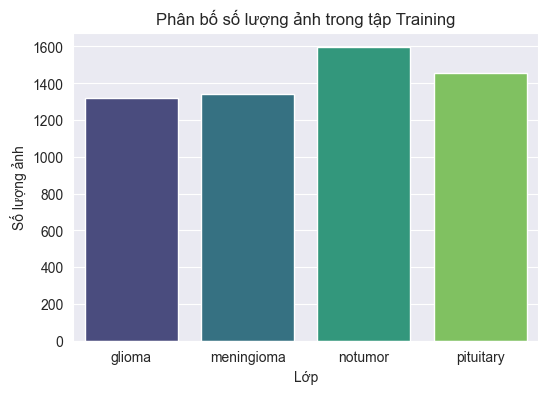

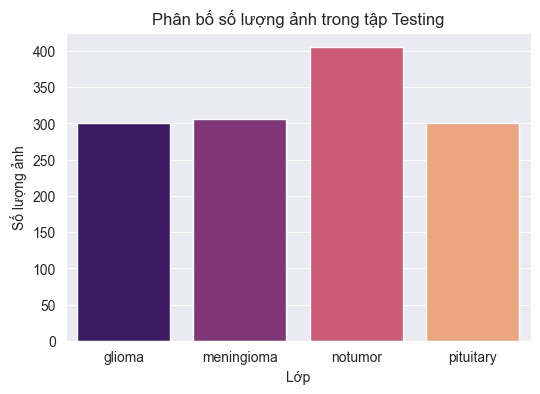

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Đếm số lượng ảnh mỗi lớp
train_counts = Counter(y_train)
test_counts = Counter(y_test)

# Tạo DataFrame
train_df = pd.DataFrame({
    "Lớp": list(train_counts.keys()),
    "Số lượng": list(train_counts.values())
})

test_df = pd.DataFrame({
    "Lớp": list(test_counts.keys()),
    "Số lượng": list(test_counts.values())
})

# Biểu đồ tập huấn luyện
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x="Lớp", y="Số lượng", hue="Lớp", palette="viridis", legend=False)
plt.title("Phân bố số lượng ảnh trong tập Training")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.show()

# Biểu đồ tập kiểm tra
plt.figure(figsize=(6,4))
sns.barplot(data=test_df, x="Lớp", y="Số lượng", hue="Lớp", palette="magma", legend=False)
plt.title("Phân bố số lượng ảnh trong tập Testing")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8188976].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.9212599].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05511811..2.007874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8503937].


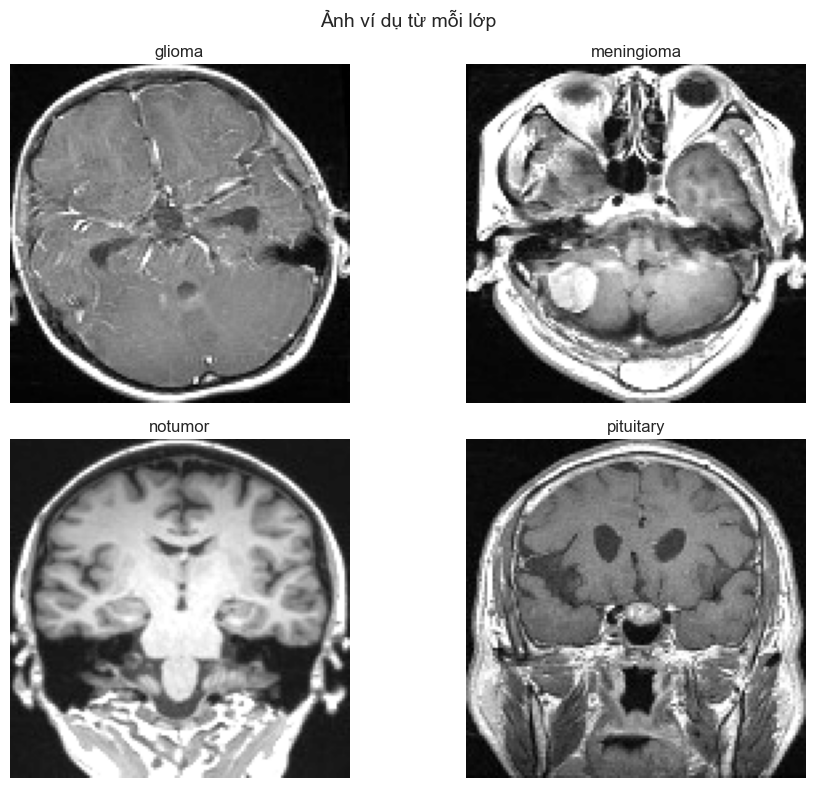

In [40]:
import random

plt.figure(figsize=(10, 8))
classes = np.unique(y_train)
for i, label in enumerate(classes):
    img_idx = np.where(y_train == label)[0]
    img = X_train[random.choice(img_idx)]
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
plt.suptitle("Ảnh ví dụ từ mỗi lớp", fontsize=14)
plt.tight_layout()
plt.show()

II. Phân tích và trực quan hóa dữ liệu.

In [41]:
# TRÍCH XUẤT HOG
def extract_hog_features(images):
    hog_features = []
    for img in tqdm(images, desc="Trích xuất HOG", ncols=80):
        # Chuyển sang grayscale vì HOG không cần màu
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        # Tính HOG
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )
        hog_features.append(feat)
    return np.array(hog_features)

print("\nBắt đầu trích xuất HOG cho tập train...")
X_train_hog = extract_hog_features(X_train)

print("\nBắt đầu trích xuất HOG cho tập test...")
X_test_hog = extract_hog_features(X_test)

print("\nHoàn tất trích xuất HOG.")
print("Kích thước đặc trưng:")
print("X_train_hog:", X_train_hog.shape)
print("X_test_hog:", X_test_hog.shape)


Bắt đầu trích xuất HOG cho tập train...


Trích xuất HOG: 100%|██████████████████████| 5712/5712 [00:45<00:00, 126.06it/s]



Bắt đầu trích xuất HOG cho tập test...


Trích xuất HOG: 100%|██████████████████████| 1311/1311 [00:10<00:00, 127.16it/s]



Hoàn tất trích xuất HOG.
Kích thước đặc trưng:
X_train_hog: (5712, 8100)
X_test_hog: (1311, 8100)


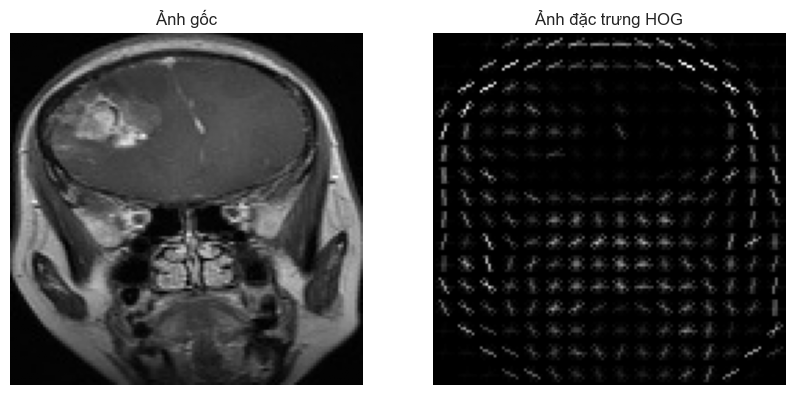

In [42]:
# Chọn 1 ảnh từ tập train
img = X_train[0]

# Chuyển sang grayscale
gray = rgb2gray(img)

# Tính HOG và ảnh trực quan hóa
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True,
    transform_sqrt=True
)

# Hiển thị
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title('Ảnh đặc trưng HOG')
plt.axis('off')

plt.show()

1. PCA

1.1. Phân tích dữ liệu.

Kích thước dữ liệu huấn luyện: (5712, 128, 128, 3)
Mean pixel: 0.5510
Std pixel:  0.3897
Min pixel:  0.0000
Max pixel:  2.0079


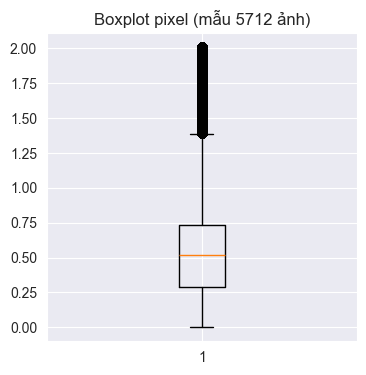

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# X_train có dạng (n_samples, height, width, channels)
print("Kích thước dữ liệu huấn luyện:", X_train.shape)

# Lấy ngẫu nhiên một số ảnh nhỏ để thống kê
num_images = X_train_hog.shape[0]
idx = np.random.choice(X_train.shape[0], num_images, replace=False)
subset = X_train[idx]

# Gộp tất cả pixel ảnh
sample_pixels = subset.flatten()

# Tính thống kê
mean_val = np.mean(sample_pixels)
std_val = np.std(sample_pixels)
min_val = np.min(sample_pixels)
max_val = np.max(sample_pixels)

print(f"Mean pixel: {mean_val:.4f}")
print(f"Std pixel:  {std_val:.4f}")
print(f"Min pixel:  {min_val:.4f}")
print(f"Max pixel:  {max_val:.4f}")

plt.figure(figsize=(4,4))
plt.boxplot(sample_pixels, vert=True)
plt.title(f"Boxplot pixel (mẫu {num_images} ảnh)")
plt.show()

1.2. Trực quan hóa dữ liệu.

Explained variance của từng thành phần PC1–PC6: [0.04991981 0.03898201 0.01892148 0.01791301 0.01546009 0.01361282]


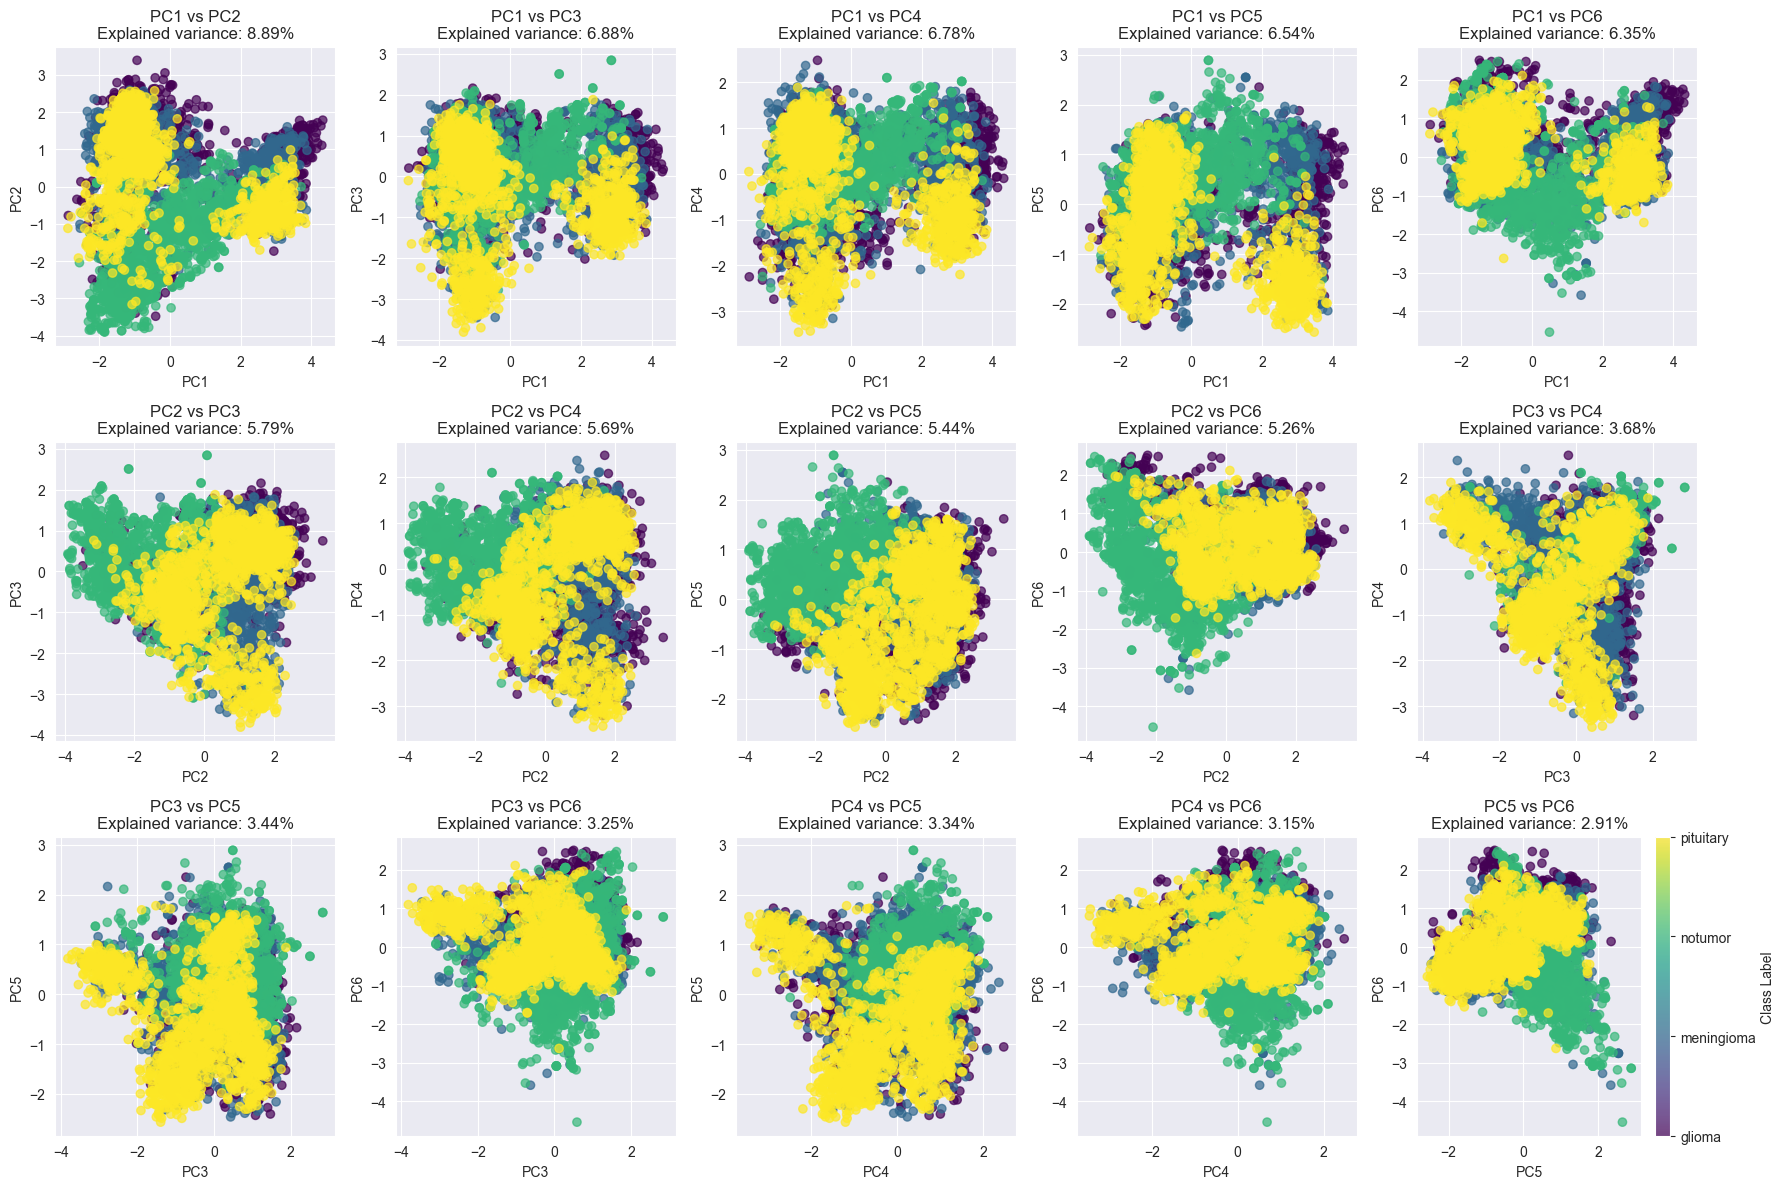

In [44]:
import matplotlib.pyplot as plt
import itertools
from sklearn.decomposition import PCA

class_names = label_encoder.classes_  # tên nhãn tương ứng với số

# --- Áp dụng PCA ---
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_train_hog)

# --- Tính explained variance ---
explained_var = pca.explained_variance_ratio_
print("Explained variance của từng thành phần PC1–PC6:", explained_var)

# --- Vẽ scatter plot từng cặp 2 thành phần ---
pairs = list(itertools.combinations(range(6), 2))

plt.figure(figsize=(18, 12))
for i, (x_idx, y_idx) in enumerate(pairs):
    plt.subplot(3, 5, i+1)
    scatter = plt.scatter(
        X_pca[:, x_idx], X_pca[:, y_idx],
        c=y_train_encoded, cmap='viridis', alpha=0.7
    )
    plt.xlabel(f"PC{x_idx+1}")
    plt.ylabel(f"PC{y_idx+1}")

    # Explained variance của cặp
    pair_var = explained_var[x_idx] + explained_var[y_idx]
    plt.title(f"PC{x_idx+1} vs PC{y_idx+1}\nExplained variance: {pair_var:.2%}")
    plt.grid(True)

# --- Thêm colorbar với nhãn ---
cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label('Class Label')

plt.tight_layout()
plt.show()

In [ ]:
# --- Áp dụng PCA ---
pca = PCA().fit(X_train_hog)

# Tính phương sai tích lũy
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Xác định số lượng thành phần cần để giữ 90% thông tin
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Số thành phần PCA cần để giữ 90% phương sai: {n_components_90}")

# --- Vẽ biểu đồ ---
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o', color='b')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% phương sai')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} thành phần')
plt.title("Biểu đồ tích lũy phương sai theo số thành phần PCA")
plt.xlabel("Số thành phần PCA")
plt.ylabel("Phần trăm phương sai tích lũy")
plt.legend()
plt.grid(True)
plt.show()

Số chiều sau khi giữ 90% phương sai: 1167
Adjusted Rand Index (1167 PC): 0.121
Silhouette Score (1167 PC): 0.077


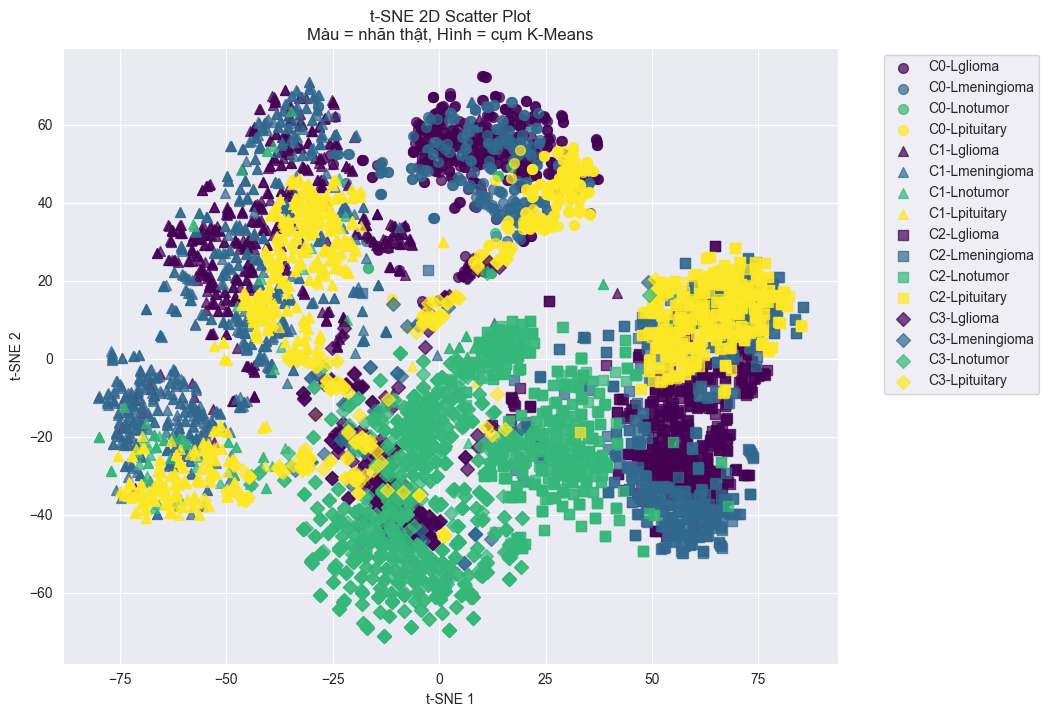

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

class_names = label_encoder.classes_

# --- PCA giữ 90% phương sai ---
pca_full = PCA(n_components=0.9)
X_pca_full = pca_full.fit_transform(X_train_hog)
print("Số chiều sau khi giữ 90% phương sai:", X_pca_full.shape[1])

# --- K-Means trên toàn bộ 1167 chiều ---
k = len(np.unique(y_train_encoded))
kmeans_full = KMeans(n_clusters=k, random_state=42)
clusters_full = kmeans_full.fit_predict(X_pca_full)

# --- Đánh giá phân cụm ---
ari_full = adjusted_rand_score(y_train_encoded, clusters_full)
sil_score_full = silhouette_score(X_pca_full, clusters_full)
print(f"Adjusted Rand Index (1167 PC): {ari_full:.3f}")
print(f"Silhouette Score (1167 PC): {sil_score_full:.3f}")

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- t-SNE 2D trên dữ liệu PCA giữ 90% (1167 chiều) ---
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca_full)

# Marker cho các cụm
markers = ['o', '^', 's', 'D', 'v', 'P', '*']

plt.figure(figsize=(10, 8))
for cluster_id in range(k):
    for label_id in range(len(class_names)):
        mask = (clusters_full == cluster_id) & (y_train_encoded == label_id)
        plt.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            c=[plt.cm.viridis(label_id / (len(class_names)-1))],
            marker=markers[cluster_id % len(markers)],
            label=f"C{cluster_id}-L{class_names[label_id]}",
            alpha=0.7,
            s=50
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE 2D Scatter Plot\nMàu = nhãn thật, Hình = cụm K-Means")

# Chỉ hiển thị legend không bị trùng
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

2. LDA

2.1. Phân tích dữ liệu.

2.2. Trực quan hóa dữ liệu.

III. Phân cụm dữ liệu.

In [19]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# --- SỬA ĐỔI BẮT ĐẦU ---

# Giả sử bạn có:
# X_train_hog (5700, 8100) - Đặc trưng HOG của tập train
# y_train (5700,)          - Nhãn của tập train (ví dụ: 0, 1, 2, 3)
# X_test_hog (1300, 8100)   - Đặc trưng HOG của tập test
# y_test (1300,)            - Nhãn của tập test (cần thiết để tạo y_all)

# Nếu bạn không có y_test, bạn không thể tạo y_all và không thể tính Adjusted Rand Index.
# Bạn vẫn có thể tính Silhouette Score mà không cần y_all.
# Giả sử ở đây là bạn có y_test:
y_all = np.hstack((y_train_encoded, y_test_encoded))

# 1. Chuẩn hóa dữ liệu (Rất quan trọng cho LDA)
# Fit CHỈ trên tập train để tránh rò rỉ dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
# Dùng scaler đã fit để transform tập test
X_test_scaled = scaler.transform(X_test_hog)

# Bây giờ tạo X_all_scaled từ các mảnh đã chuẩn hóa
X_all_scaled = np.vstack((X_train_scaled, X_test_scaled))
# Kích thước X_all_scaled sẽ là (7000, 8100)

# --- SỬA ĐỔI KẾT THÚC ---


# 2. Áp dụng LDA
# Số thành phần (n_components) của LDA phải <= (số_lớp - 1)
num_classes = len(np.unique(y_train_encoded))
n_components = num_classes - 1

lda = LinearDiscriminantAnalysis(n_components=n_components)

# 3. Fit LDA (chỉ trên tập train đã chuẩn hóa)
# Đây là lúc LDA "học" cách phân tách các lớp
lda.fit(X_train_scaled, y_train_encoded) # <-- Chỉ dùng X_train_scaled

# 4. Transform toàn bộ dữ liệu (đã chuẩn hóa)
# Áp dụng phép chiếu đã học lên toàn bộ 7000 ảnh
X_all_lda = lda.transform(X_all_scaled) # <-- Dùng X_all_scaled

# X_all_lda bây giờ có kích thước (7000, n_components)
# Ví dụ, nếu bạn có 4 loại u, kích thước sẽ là (7000, 3)
# THAY VÌ (7000, 1167) như của PCA!

# 5. Phân cụm và đánh giá (trên dữ liệu đã giảm chiều bằng LDA)
# (y_all là nhãn của 7000 ảnh)
kmeans = KMeans(n_clusters=num_classes, random_state=42)
clusters_lda = kmeans.fit_predict(X_all_lda)

ari_lda = adjusted_rand_score(y_all, clusters_lda)
sil_lda = silhouette_score(X_all_lda, clusters_lda)

print(f"--- Kết quả sau khi dùng LDA ({n_components} chiều) ---")
print(f"Adjusted Rand Index (LDA): {ari_lda:.3f}")
print(f"Silhouette Score (LDA): {sil_lda:.3f}")

--- Kết quả sau khi dùng LDA (3 chiều) ---
Adjusted Rand Index (LDA): 0.873
Silhouette Score (LDA): 0.680


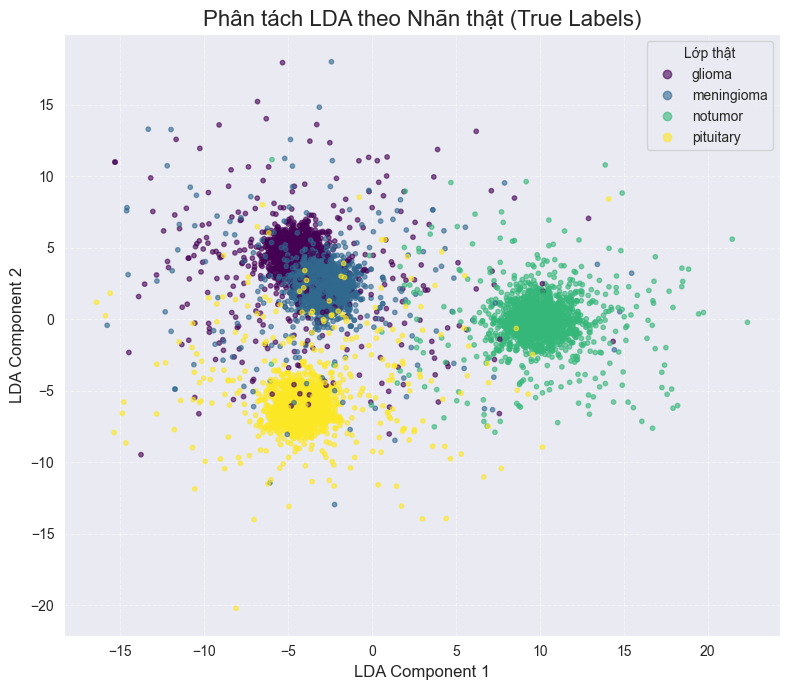

In [23]:
import matplotlib.pyplot as plt
import numpy as np
# Hai dòng dưới đây không còn cần thiết nếu chỉ vẽ 1 biểu đồ
# from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.patches as mpatches

# --- Bạn đã có các biến này từ trước ---
# label_encoder (đã được fit_transform)
# X_all_lda
# y_all
# num_classes
# n_components
# --------------------------------------

# 1. Tự động lấy tên lớp từ LabelEncoder
class_name_map = {i: class_name for i, class_name in enumerate(label_encoder.classes_)}

# 2. Thiết lập biểu đồ (CHỈ 1 CỘT)
# Thay đổi từ (1, 2, figsize=(16, 7)) thành (1, 1, figsize=(8, 7))
fig, ax1 = plt.subplots(1, 1, figsize=(8, 7))

cmap = plt.get_cmap('viridis', num_classes)

# --- Biểu đồ 1: Nhãn thật (Ground Truth) ---

if n_components == 1:
    y_jitter = np.random.uniform(-0.1, 0.1, size=len(y_all))
    scatter1 = ax1.scatter(X_all_lda[:, 0], y_jitter, c=y_all, cmap=cmap, alpha=0.6, s=10)
    ax1.set_xlabel('LDA Component 1', fontsize=12)
    ax1.set_yticks([])
elif n_components >= 2:
    scatter1 = ax1.scatter(X_all_lda[:, 0], X_all_lda[:, 1], c=y_all, cmap=cmap, alpha=0.6, s=10)
    ax1.set_xlabel('LDA Component 1', fontsize=12)
    ax1.set_ylabel('LDA Component 2', fontsize=12)

# Đặt tiêu đề và chú giải
ax1.set_title(f'Phân tách LDA theo Nhãn thật (True Labels)', fontsize=16)
handles, labels_text = scatter1.legend_elements()

# Dọn dẹp chuỗi LaTeX
cleaned_labels = [l.replace('$\\mathdefault{', '').replace('}$', '') for l in labels_text]
new_labels = [class_name_map[int(label)] for label in cleaned_labels]

ax1.legend(handles, new_labels, title="Lớp thật")
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Biểu đồ 2 và Tiêu đề chung ĐÃ BỊ XÓA ---

plt.tight_layout()
plt.show() # Hiển thị biểu đồ

In [31]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # <<< THÊM THƯ VIỆN NÀY
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Tắt các cảnh báo về convergence của Logistic Regression cho gọn
warnings.filterwarnings('ignore')

# --- 1. Chuẩn bị mô hình ---
model_nb = GaussianNB(var_smoothing=0.01)
model_lr = LogisticRegression(max_iter=1000, C=0.01)

# --- 2. Huấn luyện & Đánh giá với PCA ---

print("="*30)
print(f"ĐÁNH GIÁ VỚI PCA ({n_components_90} thành phần)")
print("="*30)

# Áp dụng PCA với số thành phần đã chọn
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_hog)
X_test_pca = pca.transform(X_test_hog)

# a) Gaussian Naive Bayes + PCA
print("\n--- Gaussian Naive Bayes (với PCA) ---")
model_nb.fit(X_train_pca, y_train_encoded)
y_pred_nb_pca = model_nb.predict(X_test_pca)
acc_nb_pca = accuracy_score(y_test_encoded, y_pred_nb_pca)

print(f"Độ chính xác: {acc_nb_pca:.4f}")
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_nb_pca, target_names=label_encoder.classes_))


# b) Logistic Regression + PCA
print("\n--- Logistic Regression (với PCA) ---")
model_lr.fit(X_train_pca, y_train_encoded)
y_pred_lr_pca = model_lr.predict(X_test_pca)
acc_lr_pca = accuracy_score(y_test_encoded, y_pred_lr_pca)

print(f"Độ chính xác: {acc_lr_pca:.4f}")
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_lr_pca, target_names=label_encoder.classes_))


# -----------------------------------------------------------------
# !!! BỔ SUNG PHẦN CÒN THIẾU ĐỂ TẠO LDA TRƯỚC KHI DÙNG !!!
# -----------------------------------------------------------------
# --- 3. Khởi tạo và áp dụng LDA ---

# LDA là phương pháp 'có giám sát' (supervised), nên cần cả X và y
# Số thành phần của LDA thường là (số_lớp - 1)
num_classes = len(label_encoder.classes_)
n_components_lda = num_classes - 1

print(f"\nĐang áp dụng LDA (giảm xuống {n_components_lda} thành phần)...")
lda = LinearDiscriminantAnalysis(n_components=n_components_lda)

# Fit và transform trên tập train (cần cả y_train_encoded)
X_train_lda = lda.fit_transform(X_train_hog, y_train_encoded)

# Chỉ transform trên tập test
X_test_lda = lda.transform(X_test_hog)
# -----------------------------------------------------------------


# --- 4. Huấn luyện & Đánh giá với LDA ---

print("\n" + "="*30)
# Dòng này bây giờ sẽ chạy được
print(f"ĐÁNH GIÁ VỚI LDA ({X_train_lda.shape[1]} thành phần)")
print("="*30)

# a) Gaussian Naive Bayes + LDA
print("\n--- Gaussian Naive Bayes (với LDA) ---")
model_nb.fit(X_train_lda, y_train_encoded)
y_pred_nb_lda = model_nb.predict(X_test_lda)
acc_nb_lda = accuracy_score(y_test_encoded, y_pred_nb_lda)

print(f"Độ chính xác: {acc_nb_lda:.4f}")
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_nb_lda, target_names=label_encoder.classes_))

# b) Logistic Regression + LDA
print("\n--- Logistic Regression (với LDA) ---")
model_lr.fit(X_train_lda, y_train_encoded)
y_pred_lr_lda = model_lr.predict(X_test_lda)
acc_lr_lda = accuracy_score(y_test_encoded, y_pred_lr_lda)

print(f"Độ chính xác: {acc_lr_lda:.4f}")
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_lr_lda, target_names=label_encoder.classes_))


# --- 5. Tổng kết so sánh ---
print("\n" + "="*30)
print("TỔNG KẾT ĐỘ CHÍNH XÁC (Accuracy)")
print("="*30)
print(f"Naive Bayes + PCA: \t{acc_nb_pca:.4f}")
print(f"Logistic Reg + PCA: \t{acc_lr_pca:.4f}")
print(f"Naive Bayes + LDA: \t{acc_nb_lda:.4f}")
print(f"Logistic Reg + LDA: \t{acc_lr_lda:.4f}")

ĐÁNH GIÁ VỚI PCA (1167 thành phần)

--- Gaussian Naive Bayes (với PCA) ---
Độ chính xác: 0.5751
Classification Report:
              precision    recall  f1-score   support

      glioma       0.48      0.28      0.36       300
  meningioma       0.73      0.36      0.48       306
     notumor       0.93      0.66      0.77       405
   pituitary       0.42      0.97      0.58       300

    accuracy                           0.58      1311
   macro avg       0.64      0.57      0.55      1311
weighted avg       0.66      0.58      0.57      1311


--- Logistic Regression (với PCA) ---
Độ chính xác: 0.8101
Classification Report:
              precision    recall  f1-score   support

      glioma       0.78      0.70      0.74       300
  meningioma       0.72      0.62      0.67       306
     notumor       0.88      0.95      0.92       405
   pituitary       0.82      0.91      0.86       300

    accuracy                           0.81      1311
   macro avg       0.80      0.80    

In [32]:
# --- Tạo một danh sách để lưu kết quả ---
results_list = []

# --- 1. Naive Bayes + PCA ---
model_nb.fit(X_train_pca, y_train_encoded)
acc_train_nb_pca = accuracy_score(y_train_encoded, model_nb.predict(X_train_pca))
acc_test_nb_pca = accuracy_score(y_test_encoded, model_nb.predict(X_test_pca))
results_list.append({
    "Model": "Naive Bayes + PCA",
    "Train Accuracy": acc_train_nb_pca,
    "Test Accuracy": acc_test_nb_pca
})

# --- 2. Logistic Regression + PCA ---
model_lr.fit(X_train_pca, y_train_encoded)
acc_train_lr_pca = accuracy_score(y_train_encoded, model_lr.predict(X_train_pca))
acc_test_lr_pca = accuracy_score(y_test_encoded, model_lr.predict(X_test_pca))
results_list.append({
    "Model": "Logistic Reg + PCA",
    "Train Accuracy": acc_train_lr_pca,
    "Test Accuracy": acc_test_lr_pca
})

# --- 3. Naive Bayes + LDA ---
model_nb.fit(X_train_lda, y_train_encoded)
acc_train_nb_lda = accuracy_score(y_train_encoded, model_nb.predict(X_train_lda))
acc_test_nb_lda = accuracy_score(y_test_encoded, model_nb.predict(X_test_lda))
results_list.append({
    "Model": "Naive Bayes + LDA",
    "Train Accuracy": acc_train_nb_lda,
    "Test Accuracy": acc_test_nb_lda
})

# --- 4. Logistic Regression + LDA ---
model_lr.fit(X_train_lda, y_train_encoded)
acc_train_lr_lda = accuracy_score(y_train_encoded, model_lr.predict(X_train_lda))
acc_test_lr_lda = accuracy_score(y_test_encoded, model_lr.predict(X_test_lda))
results_list.append({
    "Model": "Logistic Reg + LDA",
    "Train Accuracy": acc_train_lr_lda,
    "Test Accuracy": acc_test_lr_lda
})

# --- In kết quả ra dạng bảng đẹp ---
df_results = pd.DataFrame(results_list)
print(df_results.to_string(index=False, float_format="%.4f"))

             Model  Train Accuracy  Test Accuracy
 Naive Bayes + PCA          0.7351         0.5751
Logistic Reg + PCA          0.8822         0.8101
 Naive Bayes + LDA          1.0000         0.7239
Logistic Reg + LDA          0.9996         0.7223
